In [1]:
import h5py
from lace.cosmo import cosmology
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from w1_w2 import compute_w1_w2
from forestflow import pcross

# Computing P3D first

(In the future, all this should be replaced by calling a function that computes P3D)

In [2]:
wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log
bias_hcd, bias_lya = 2, -0.18

In [3]:
# MW11 cosmology, for example
hubble, z = 0.71, 2.5
ombh2, omegam = 0.046*(hubble**2), 0.27
omch2 = omegam*(hubble**2)-ombh2
ns, As = 0.96, 2e-9
Fhcd = 0.9779

cosmo = cosmology.Cosmology()
cosmo.CAMBparams.set_cosmology(H0=100*hubble, ombh2=ombh2, omch2=omch2)
cosmo.CAMBparams.InitPower.set_params(As=As, ns=ns)
print('WARNING: Changed to MW11 cosmology (It does not affect the f(NHI, X) function)')

In [4]:
fn_file = '/pscratch/sd/l/lflores/astrid_hcd_outputs/fn_pyigm/fn_pyigm1'

with h5py.File(fn_file, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    logNHI_max = f.attrs['logNHI_max']
    logNHI_min = f.attrs['logNHI_min']
    print('----------------') 
    print('Data:')
    print(f.keys())

    NHirange = np.linspace(logNHI_min, logNHI_max) 
    logfNHiX = np.interp(NHirange, f['logNhi'][:], f['fn'][:][:, 0])
    fNHiX = 10**(logfNHiX)

Atributes:
Redshift = 2.5
logNHI_max = 21.3
logNHI_min = 17.2
----------------
Data:
<KeysViewHDF5 ['fn', 'logNhi']>


In [5]:
k_w1w2, w1, w2 = compute_w1_w2(wave, NHirange, fNHiX, z, hubble, omegam, resample=True)
bias_hcd_flux = -2*w2[1]/Fhcd  # Warning, this depends a lot on the cosmology

mu = np.linspace(0, 1, 11)
k = np.logspace(-2.5, 0.5, len(k_w1w2))
k_los = k*mu[:, None]
k_perp = np.sqrt(k**2 - k_los**2)

w1_grid = np.interp(k_los, k_w1w2, w1)
w2_grid = np.interp(k_los, k_w1w2, w2)

plin = cosmo.get_linP_Mpc(z, k)
dkms_dMpc = cosmo.get_dkms_dMpc(z)
k_d = 0.08*dkms_dMpc  # Mpc^-1
exp = np.exp(-(k_los**2/k_d**2))

p3d_lya = (bias_lya**2)*((1+mu[:, None]**2)**2)*exp*plin
p3d_hcd = (w2_grid**2)*((bias_hcd+mu[:, None]**2)**2)*plin
p3d_lyahcd = w2_grid*(np.abs(bias_hcd) + mu[:, None]**2)*np.abs(bias_lya)*(1 + mu[:, None]**2)*plin*np.sqrt(exp)
p3d_total = p3d_hcd + p3d_lya + 2*p3d_lyahcd

# Px

In [6]:
cosmo_dict = {
    'H0': 100*hubble,
    'ombh2': ombh2,
    'omch2': omch2,
    'ns': ns,
    'As': As}

r_bins = [0.27, 0.5, 0.9, 1.64, 2.98, 5.41]
print('Radial edges:',  r_bins, '[Mpc]')

Radial edges: [0.27, 0.5, 0.9, 1.64, 2.98, 5.41] [Mpc]


## HCD

In [7]:
def P3D_hcd_model(z, k, mu, p3d_params, new_cosmo_params):

    cosmo = cosmology.Cosmology(cosmo_params_dict=new_cosmo_params)
    plin = cosmo.get_linP_Mpc(z, k)

    kpar = k * mu
    w2_eval = np.interp(kpar, k_w1w2, w2)

    p3d_hcd = (w2_eval**2)*((bias_hcd+mu**2)**2)*plin

    return p3d_hcd

P3D_hcd_model.coordinates = 'k_mu'

In [8]:
px_hcd = pcross.Px_Mpc_detailed([2.5], k_w1w2, r_bins, P3D_hcd_model, max_kperp=10.0**2, p3d_params=cosmo_dict, new_cosmo_params=cosmo_dict)
px_hcd += w1

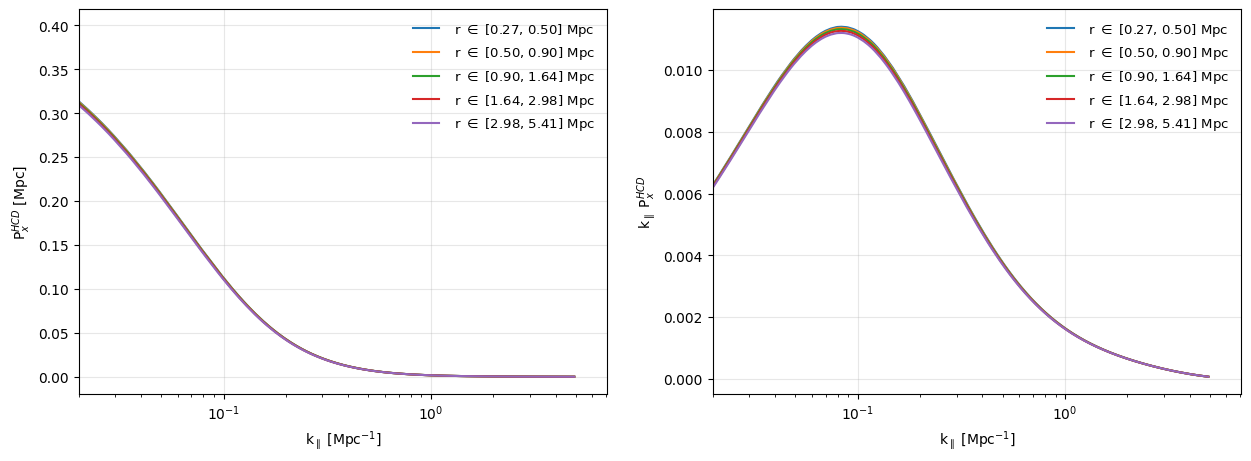

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    plt.plot(k_w1w2, px_hcd[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{HCD}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    plt.plot(k_w1w2, k_w1w2*px_hcd[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{HCD}$');

## Lya

In [10]:
def P3D_lya_model(z, k, mu, p3d_params, new_cosmo_params):

    cosmo = cosmology.Cosmology(cosmo_params_dict=new_cosmo_params)
    dkms_dMpc = cosmo.get_dkms_dMpc(z)
    k_d = 0.08*dkms_dMpc  # Mpc^-1
    plin = cosmo.get_linP_Mpc(z, k)

    kpar = k * mu
    exp = np.exp(-(kpar**2/k_d**2))
    p3d_lya = (bias_lya**2)*((1+mu**2)**2)*exp*plin

    return p3d_lya

P3D_lya_model.coordinates = 'k_mu'

In [11]:
px_lya = pcross.Px_Mpc_detailed([2.5], k_w1w2, r_bins, P3D_lya_model, max_kperp=10.0**2, p3d_params=cosmo_dict, new_cosmo_params=cosmo_dict)

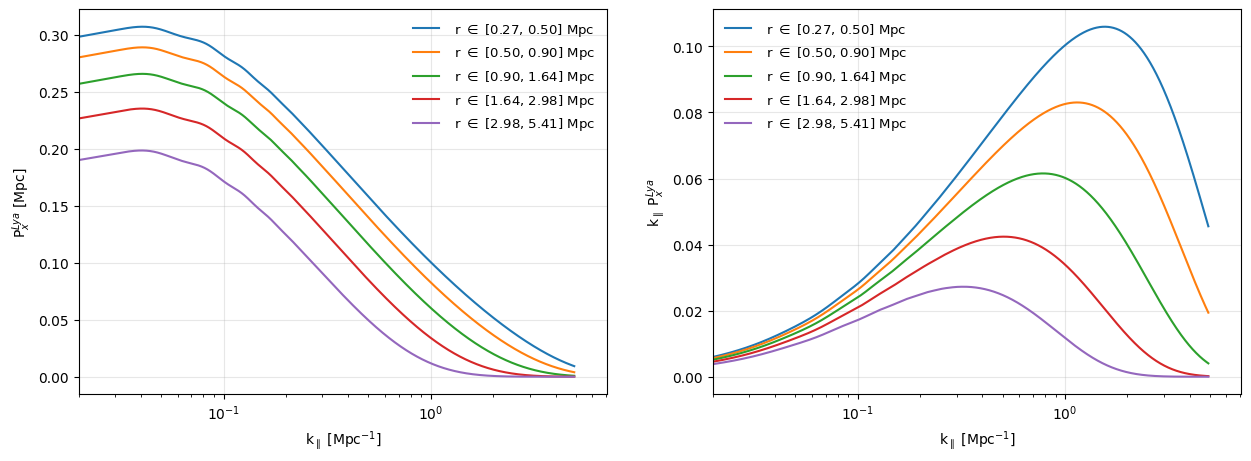

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    plt.plot(k_w1w2, px_lya[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{Lya}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    plt.plot(k_w1w2, k_w1w2*px_lya[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{Lya}$');

## HCD x Lya

In [13]:
def P3D_lyahcd_model(z, k, mu, p3d_params, new_cosmo_params):

    dkms_dMpc = cosmo.get_dkms_dMpc(z)
    k_d = 0.08*dkms_dMpc  # Mpc^-1
    plin = cosmo.get_linP_Mpc(z, k)

    kpar = k * mu
    w2_eval = np.interp(kpar, k_w1w2, w2)
    exp = np.exp(-(kpar**2/k_d**2))
    
    p3d_lyahcd = w2_eval*(np.abs(bias_hcd) + mu**2)*np.abs(bias_lya)*(1 + mu**2)*plin*np.sqrt(exp)

    return p3d_lyahcd

P3D_lyahcd_model.coordinates = 'k_mu'

In [14]:
px_lyahcd = pcross.Px_Mpc_detailed([2.5], k_w1w2, r_bins, P3D_lyahcd_model, max_kperp=10.0**2, p3d_params=cosmo_dict, new_cosmo_params=cosmo_dict)

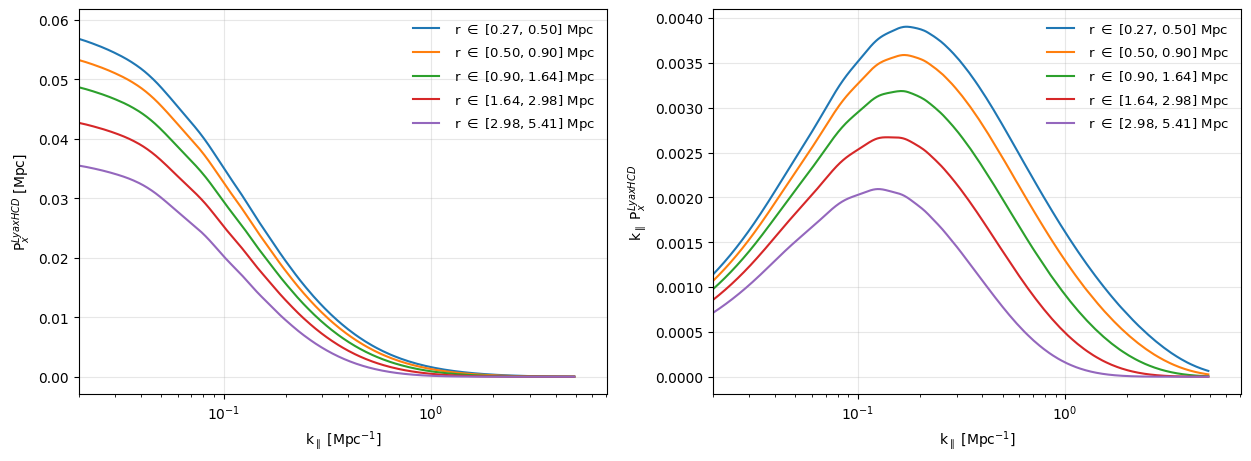

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    plt.plot(k_w1w2, px_lyahcd[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{LyaxHCD}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    plt.plot(k_w1w2, k_w1w2*px_lyahcd[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{LyaxHCD}$');

## Total

In [16]:
px_tot = px_hcd + px_lya + 2*px_lyahcd

In [17]:
def P3D_tot_model(z, k, mu, p3d_params, new_cosmo_params):

    dkms_dMpc = cosmo.get_dkms_dMpc(z)
    k_d = 0.08*dkms_dMpc  # Mpc^-1
    plin = cosmo.get_linP_Mpc(z, k)

    kpar = k * mu
    w2_eval = np.interp(kpar, k_w1w2, w2)
    exp = np.exp(-(kpar**2/k_d**2))

    p3d_hcd = (w2_eval**2)*((bias_hcd+mu**2)**2)*plin
    p3d_lya = (bias_lya**2)*((1+mu**2)**2)*exp*plin
    p3d_lyahcd = w2_eval*(np.abs(bias_hcd) + mu**2)*np.abs(bias_lya)*(1 + mu**2)*plin*np.sqrt(exp)

    return p3d_hcd + p3d_lya + 2*p3d_lyahcd

P3D_tot_model.coordinates = 'k_mu'

In [18]:
px_total = pcross.Px_Mpc_detailed([2.5], k_w1w2, r_bins, P3D_tot_model, max_kperp=10.0**2, p3d_params=cosmo_dict, new_cosmo_params=cosmo_dict)
px_total += w1

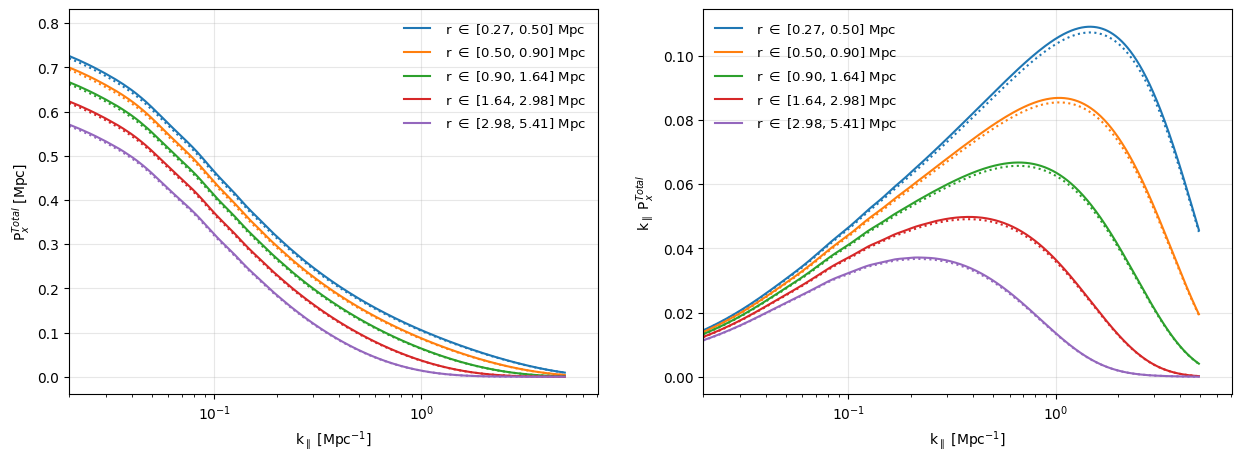

In [19]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, px_tot[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_w1w2, px_total[0, i, :], color=p[-1].get_color(), linestyle=':')

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{Total}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, k_w1w2*px_tot[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_w1w2, k_w1w2*px_total[0, i, :], color=p[-1].get_color(), linestyle=':')

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{Total}$');

# Graphics

Reading ASTRID output data

In [20]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/pxs_0.3_21.3.hdf5'

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    logNHI_min = f.attrs['logNHI_min']
    logNHI_max = f.attrs['logNHI_max']
    Lbox = f.attrs['box_size_Mpch']
    Lmbox = f.attrs['minibox_size_Mpch']
    print('----------------') 
    print('Data:')
    print(f.keys())
    k_los = f['k_los'][:]
    print('k_los shape:', k_los.shape)
    pxs_tot = f['px_tot'][:]
    print('pxs_tot shape:', pxs_tot.shape)
    pxs_lya = f['px_lya'][:]
    print('pxs_lya shape:', pxs_lya.shape)
    pxs_hcd = f['px_hcd'][:]
    print('px_hcd shape:', pxs_hcd.shape)
    pxs_lyahcd = f['px_lyahcd'][:]
    print('pxs_lyahcd shape:', pxs_lyahcd.shape)
    Cs = f['C'][()]
    print('Cs shape = ', Cs.shape)
    r_bins = f['r_bins'][:]
    print('Radial bins:', r_bins, 'Mpc/h')

Atributes:
----- WARNING ----- = Units in terms of h
Smoothing factor = 0.3
box_size_Mpch = 250
logNHI_max = 21.3
logNHI_min = 0
minibox_size_Mpch = 50.0
pixel_width_Mpch = 0.1
pixels_per_skewer = 2500
skewer_separation_Mpch = 0.5
skewers_per_side = 100
----------------
Data:
<KeysViewHDF5 ['C', 'Mask', 'k_los', 'px_3hcd', 'px_3lya', 'px_4', 'px_hcd', 'px_lya', 'px_lyahcd', 'px_tot', 'r_bins']>
k_los shape: (315,)
pxs_tot shape: (25, 5, 315)
pxs_lya shape: (25, 5, 315)
px_hcd shape: (25, 5, 315)
pxs_lyahcd shape: (25, 5, 315)
Cs shape =  (25,)
Radial bins: [0.40505051 0.73557226 1.33580019 2.42581492 4.40528312 8.        ] Mpc/h


In [21]:
k_los /= hubble  # In Mpc^-1
r_bins *= hubble  # In Mpc
pxs_tot *= hubble  # In Mpc
pxs_lya *= hubble 
pxs_hcd *= hubble 
pxs_lyahcd *= hubble 

Let's make the mean of all the boxes

In [22]:
Nmbox = pxs_tot[:, 0].shape[0]
Px_tot, Px_std_tot = np.mean(pxs_tot, axis=0), np.std(pxs_tot, axis=0)/np.sqrt(Nmbox-1)
Px_lya, Px_std_lya = np.mean(pxs_lya, axis=0), np.std(pxs_lya, axis=0)/np.sqrt(Nmbox-1)
Px_hcd, Px_std_hcd = np.mean(pxs_hcd, axis=0), np.std(pxs_hcd, axis=0)/np.sqrt(Nmbox-1)
Px_lyahcd, Px_std_lyahcd = np.mean(pxs_lyahcd, axis=0), np.std(pxs_lyahcd, axis=0)/np.sqrt(Nmbox-1)

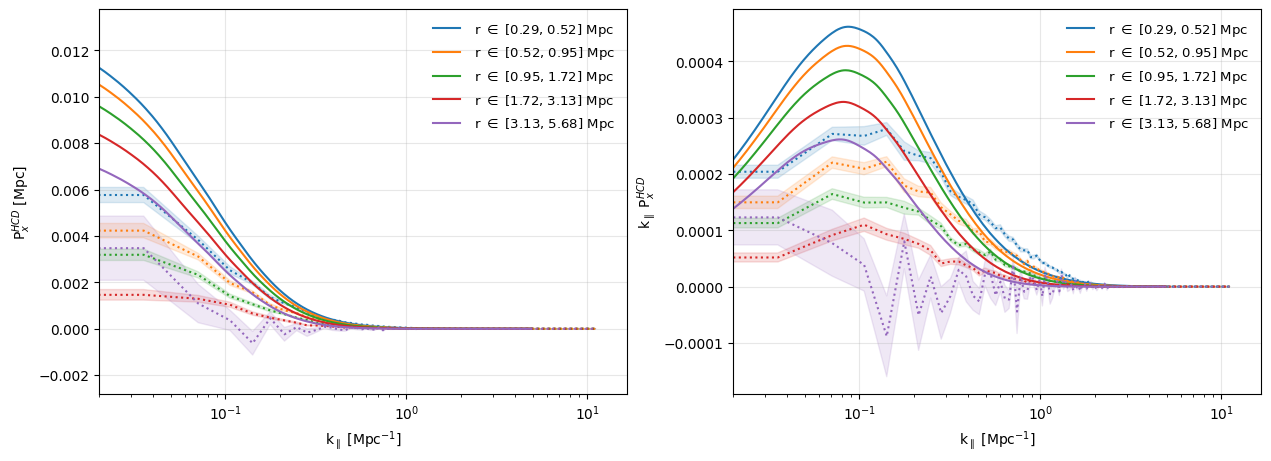

In [28]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, px_hcd[0, i, :]-w1, label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, Px_hcd[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, (Px_hcd[i]-Px_std_hcd[i]), (Px_hcd[i]+Px_std_hcd[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{HCD}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, k_w1w2*(px_hcd[0, i, :]-w1), label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, k_los*Px_hcd[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, k_los*(Px_hcd[i]-Px_std_hcd[i]), k_los*(Px_hcd[i]+Px_std_hcd[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{HCD}$');

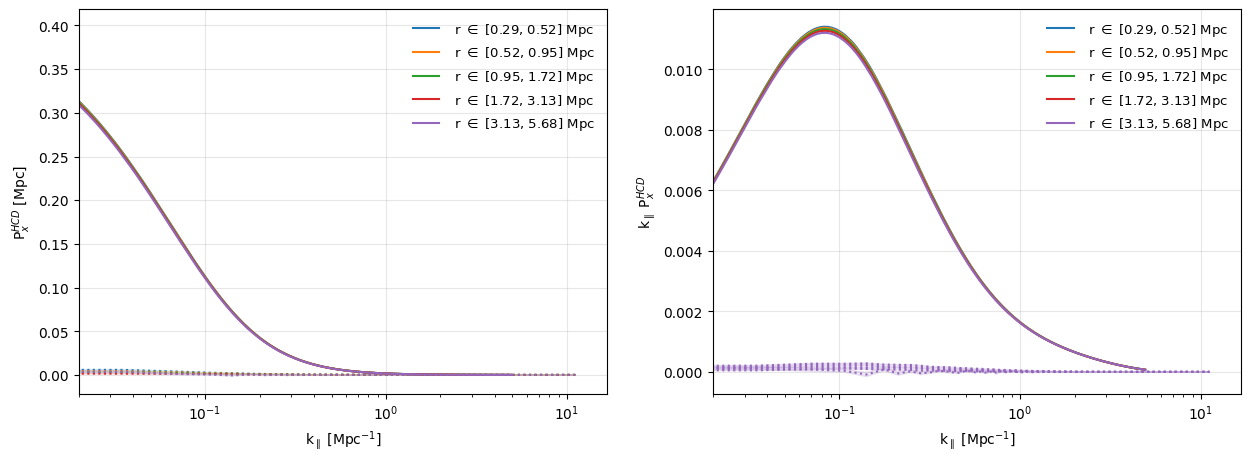

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, px_hcd[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, Px_hcd[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, (Px_hcd[i]-Px_std_hcd[i]), (Px_hcd[i]+Px_std_hcd[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{HCD}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    plt.plot(k_w1w2, k_w1w2*px_hcd[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, k_los*Px_hcd[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, k_los*(Px_hcd[i]-Px_std_hcd[i]), k_los*(Px_hcd[i]+Px_std_hcd[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{HCD}$');

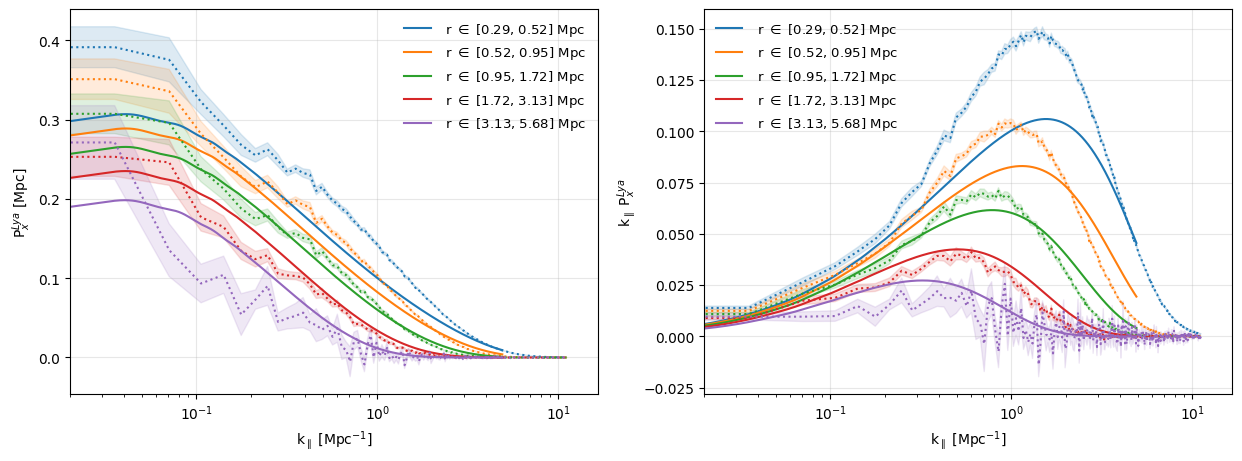

In [30]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, px_lya[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, Px_lya[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, (Px_lya[i]-Px_std_lya[i]), (Px_lya[i]+Px_std_lya[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{Lya}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, k_w1w2*(px_lya[0, i, :]), label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, k_los*Px_lya[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, k_los*(Px_lya[i]-Px_std_lya[i]), k_los*(Px_lya[i]+Px_std_lya[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{Lya}$');

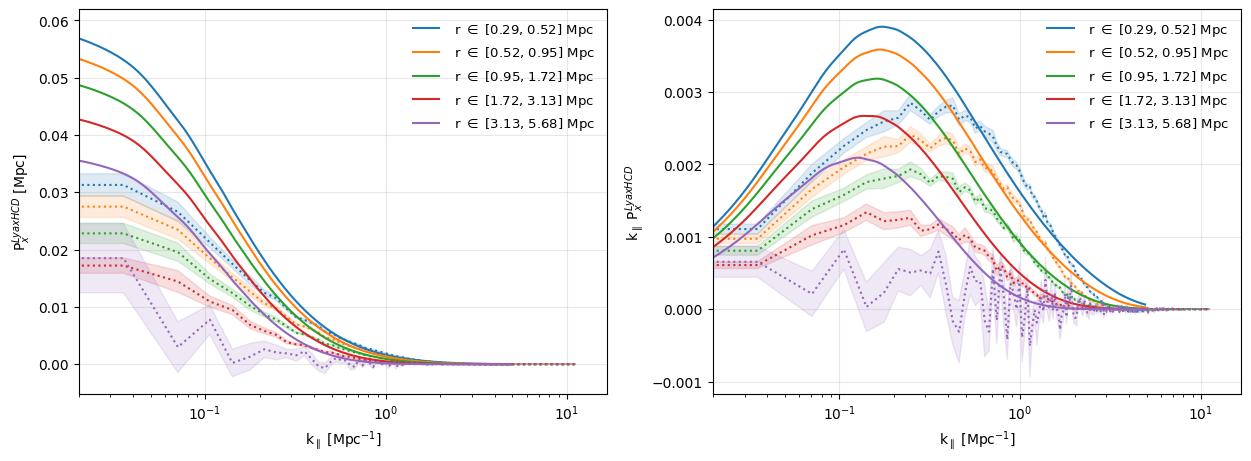

In [31]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, px_lyahcd[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, Px_lyahcd[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, (Px_lyahcd[i]-Px_std_lyahcd[i]), (Px_lyahcd[i]+Px_std_lyahcd[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{LyaxHCD}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, k_w1w2*(px_lyahcd[0, i, :]), label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, k_los*Px_lyahcd[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, k_los*(Px_lyahcd[i]-Px_std_lyahcd[i]), k_los*(Px_lyahcd[i]+Px_std_lyahcd[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{LyaxHCD}$');

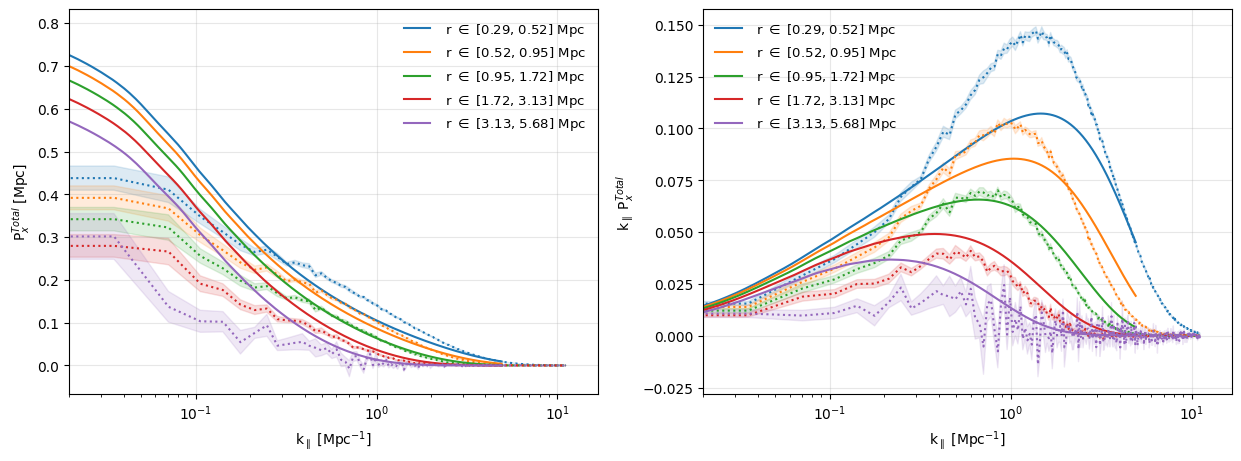

In [33]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, px_tot[0, i, :], label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, Px_tot[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, (Px_tot[i]-Px_std_tot[i]), (Px_tot[i]+Px_std_tot[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{Total}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, k_w1w2*(px_total[0, i, :]), label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, k_los*Px_tot[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, k_los*(Px_tot[i]-Px_std_tot[i]), k_los*(Px_tot[i]+Px_std_tot[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{Total}$');

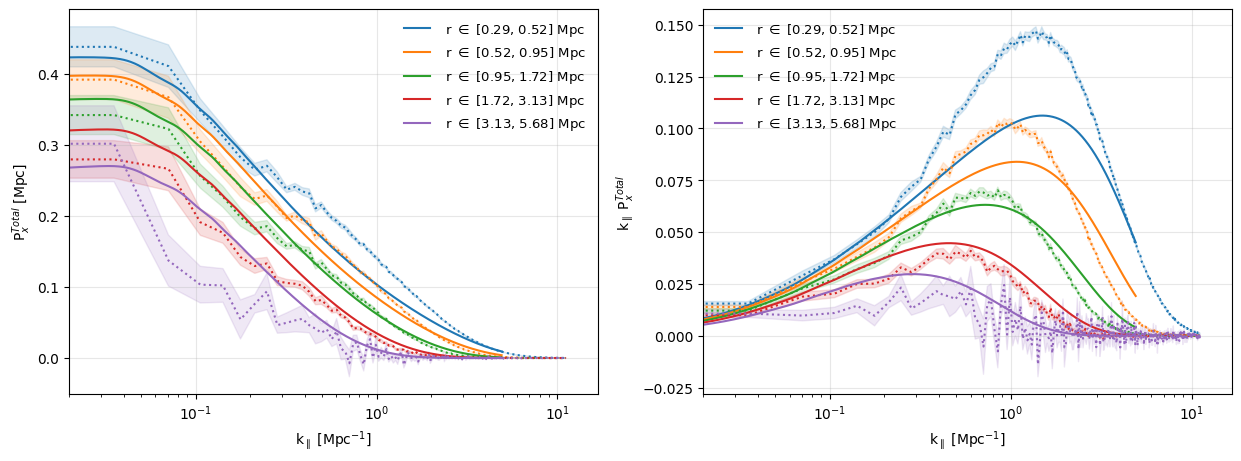

In [34]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, px_tot[0, i, :]-w1, label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, Px_tot[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, (Px_tot[i]-Px_std_tot[i]), (Px_tot[i]+Px_std_tot[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{x}^{Total}$ [Mpc]');

plt.subplot(1, 2, 2)
for i in np.arange(len(r_bins)-1):
    p = plt.plot(k_w1w2, k_w1w2*(px_total[0, i, :]-w1), label=f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]))
    plt.plot(k_los, k_los*Px_tot[i, :], linestyle=':', color=p[0].get_color())
    plt.fill_between(k_los, k_los*(Px_tot[i]-Px_std_tot[i]), k_los*(Px_tot[i]+Px_std_tot[i]), color=p[0].get_color(), alpha=0.15)

plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(left=0.02)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'k$_\parallel$ P$_{x}^{Total}$');

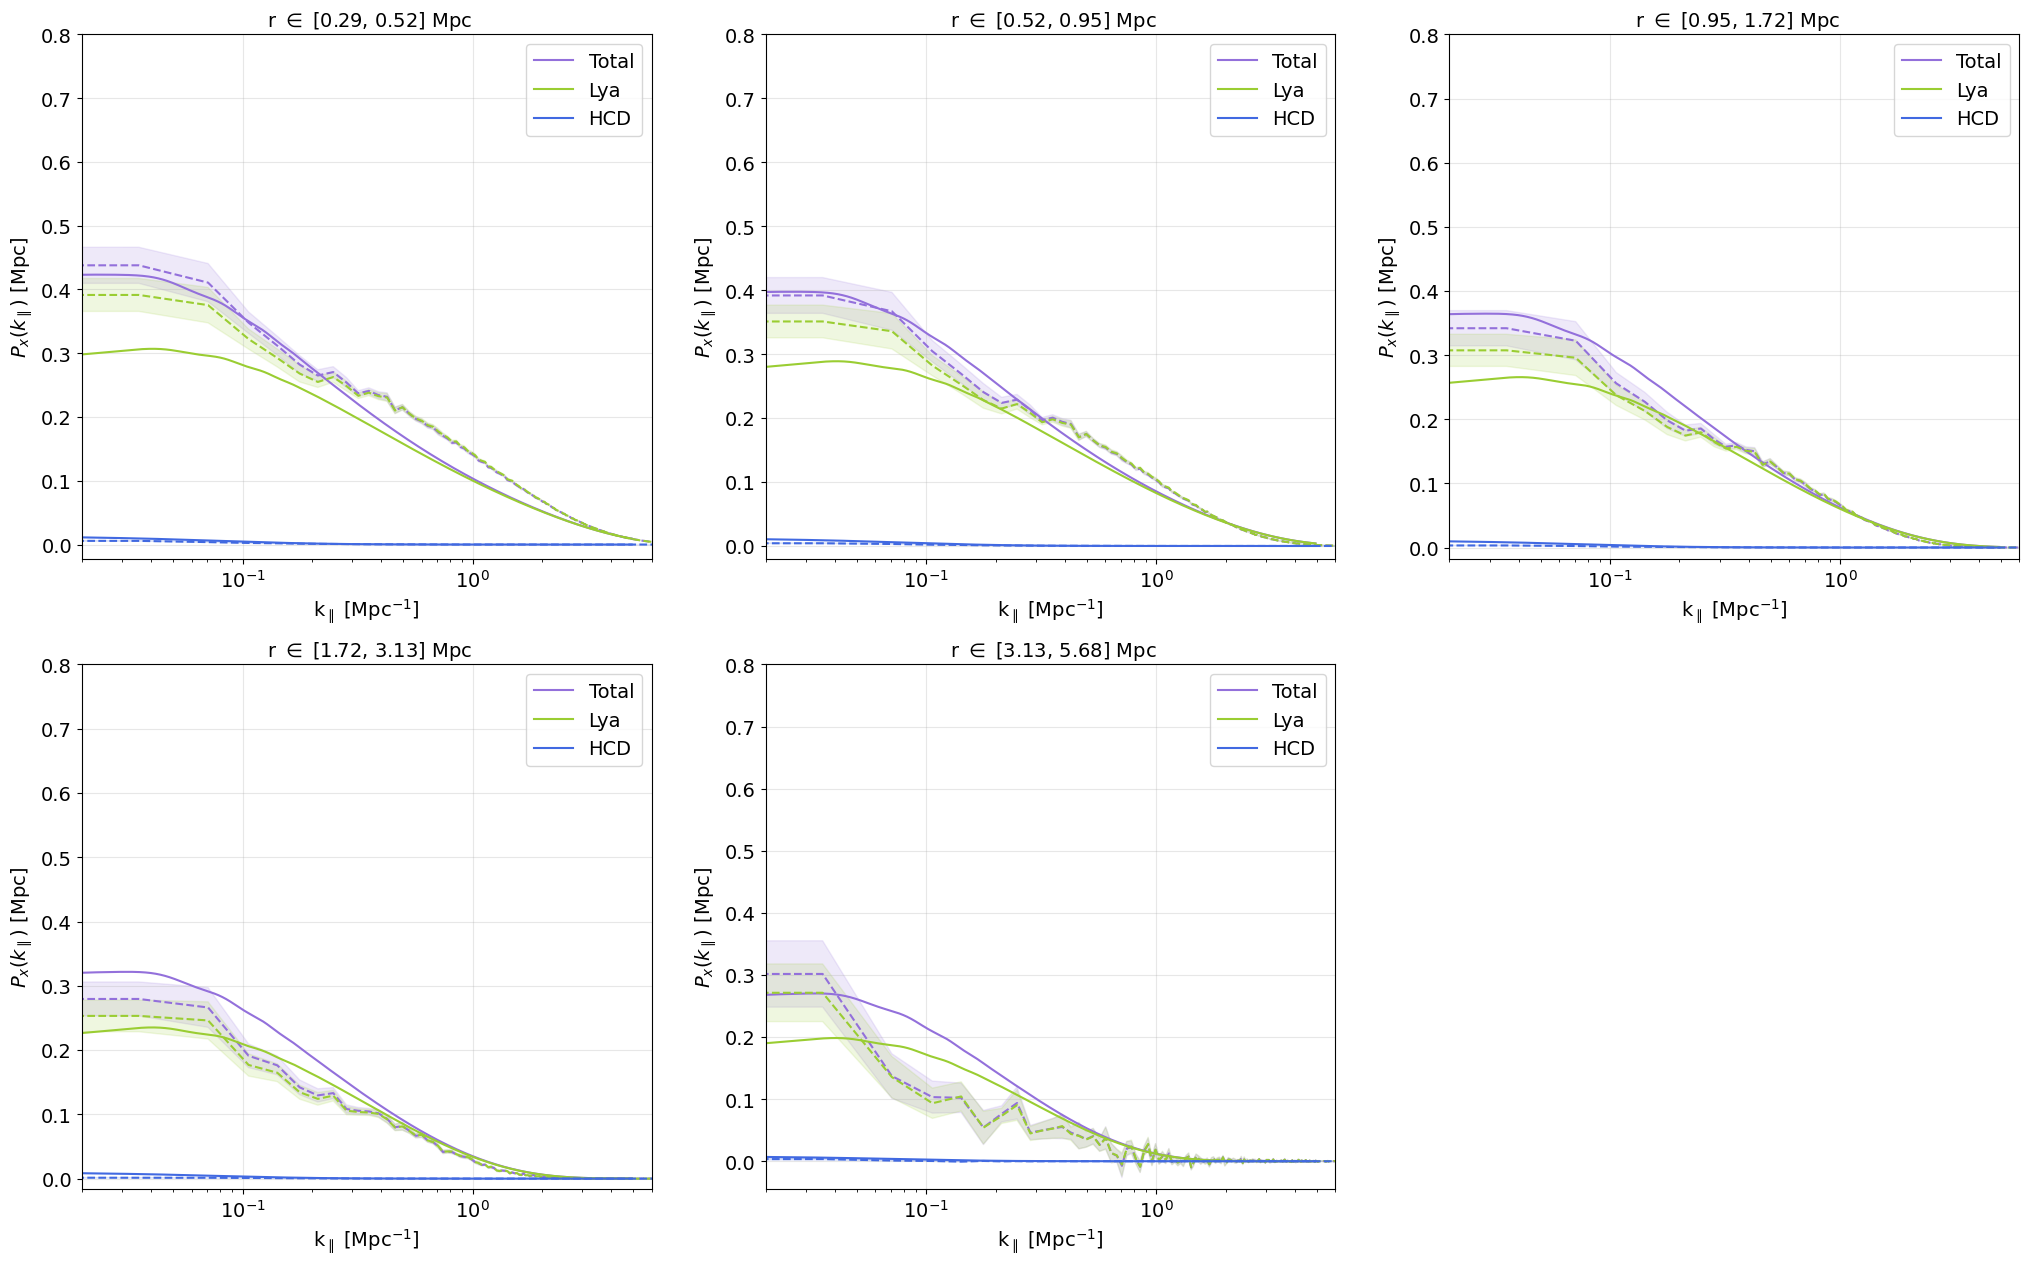

In [37]:
plt.figure(figsize=(25, 15))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_w1w2, px_tot[0, i, :]-w1, color='mediumpurple', label='Total')
    plt.plot(k_los, Px_tot[i, :], color='mediumpurple', linestyle='--')
    plt.fill_between(k_los, (Px_tot[i]-Px_std_tot[i]), (Px_tot[i]+Px_std_tot[i]), color='mediumpurple', alpha=0.15)

    plt.plot(k_w1w2, px_lya[0, i, :], color='yellowgreen', label='Lya')
    plt.plot(k_los, Px_lya[i, :], color='yellowgreen', linestyle='--')
    plt.fill_between(k_los, (Px_lya[i]-Px_std_lya[i]), (Px_lya[i]+Px_std_lya[i]), color='yellowgreen', alpha=0.15)

    plt.plot(k_w1w2, px_hcd[0, i, :]-w1, color='royalblue', label='HCD')
    plt.plot(k_los, Px_hcd[i, :], color='royalblue', linestyle='--')
    plt.fill_between(k_los, (Px_hcd[i]-Px_std_hcd[i]), (Px_hcd[i]+Px_std_hcd[i]), color='royalblue', alpha=0.15)

    plt.xscale('log')
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.xlim(0.02, 6)
    plt.ylim(top=0.8)
    plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
    plt.ylabel(r'$P_{x}(k_\parallel)$ [Mpc]', fontsize=14)
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]), fontsize=14);

    plt.savefig('plot.png', dpi=200, bbox_inches='tight')